# Customer Segmentation & Lifetime Value Analysis
### Olist Brazilian E-Commerce | RFM + K-Means + Probabilistic CLV

---

**The question:** Where should a growing e-commerce company spend its retention budget?

**The dataset:** 99K customers, 96K delivered orders, $15.4M in revenue across 2 years (2016–2018).

**The approach:**
1. **RFM scoring** — segment customers by Recency, Frequency, and Monetary value
2. **K-Means clustering** — validate that the segments are real, not arbitrary
3. **BG/NBD + Gamma-Gamma CLV** — forecast each segment's forward 12-month value

**Author:** Sivakumar Reddy Yenna

In [2]:
# =====================================================================
# Imports & Database Connection
# =====================================================================
# Credentials are loaded from a .env file at the project root.
# .env is excluded from Git (see .gitignore) to keep secrets out of
# the repo. To reproduce this notebook, create a .env file with:
#   DB_USER=postgres
#   DB_PASSWORD=your_password_here
#   DB_HOST=localhost
#   DB_PORT=5432
#   DB_NAME=olist
# =====================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from datetime import datetime
from urllib.parse import quote_plus
from dotenv import load_dotenv

# Visual settings
plt.style.use('default')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Load environment variables from .env (one level up from notebooks/)
load_dotenv(dotenv_path='../.env')

# Read database credentials from environment
DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST     = os.getenv('DB_HOST')
DB_PORT     = os.getenv('DB_PORT')
DB_NAME     = os.getenv('DB_NAME')

# Validate that all required variables loaded successfully
required_vars = {'DB_USER': DB_USER, 'DB_PASSWORD': DB_PASSWORD,
                 'DB_HOST': DB_HOST, 'DB_PORT': DB_PORT, 'DB_NAME': DB_NAME}
missing = [k for k, v in required_vars.items() if not v]
if missing:
    raise ValueError(
        f"Missing environment variables: {missing}. "
        f"Make sure a .env file exists at the project root."
    )

# Build connection string — quote_plus URL-encodes special characters
# in the password (e.g., '@' which would otherwise break the URL parsing)
engine = create_engine(
    f'postgresql+psycopg2://'
    f'{DB_USER}:{quote_plus(DB_PASSWORD)}'
    f'@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print("Imports loaded ✓")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")
print(f"Database:       {DB_NAME} @ {DB_HOST}:{DB_PORT}")
print(f"User:           {DB_USER}")
print(f"Password:       {'*' * len(DB_PASSWORD)}  (masked, loaded from .env)")

Imports loaded ✓
Pandas version: 3.0.3
NumPy version:  2.4.6
Database:       olist @ localhost:5432
User:           postgres
Password:       **************  (masked, loaded from .env)


In [3]:
# =====================================================================
# Test database connection
# =====================================================================

# Run a simple query to confirm we can talk to the database
test_query = "SELECT COUNT(*) AS total_rows FROM customer_transactions;"
test_result = pd.read_sql(test_query, engine)

print("Database connection successful ✓")
print(test_result)

Database connection successful ✓
   total_rows
0       96469


In [4]:
# =====================================================================
# Load customer_transactions view into a pandas DataFrame
# =====================================================================

query = """
SELECT
    customer_unique_id,
    order_id,
    order_purchase_timestamp,
    order_delivered_customer_date,
    payment_value,
    num_items,
    customer_state,
    customer_city
FROM customer_transactions;
"""

# Pull all 96,469 transactions into a DataFrame
df = pd.read_sql(query, engine, parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date'])

print(f"Rows loaded: {len(df):,}")
print(f"Unique customers: {df['customer_unique_id'].nunique():,}")
print(f"Columns: {list(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Rows loaded: 96,469
Unique customers: 93,349
Columns: ['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'payment_value', 'num_items', 'customer_state', 'customer_city']
Memory usage: 28.0 MB


In [5]:
# =====================================================================
# Eyeball the data
# =====================================================================

# Look at the first 5 rows
print("--- First 5 rows ---")
display(df.head())

# Summary statistics on numeric columns
print("\n--- Numeric summary ---")
display(df.describe())

# Data types — confirm timestamps parsed correctly
print("\n--- Data types ---")
print(df.dtypes)

--- First 5 rows ---


,customer_unique_id,order_id,order_purchase_timestamp,order_delivered_customer_date,payment_value,num_items,customer_state,customer_city
0,eb28e67c4c0b83846050ddfb8a35d051,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,2017-05-12 16:04:24,259.83,1,SP,santa fe do sul
1,3818d81c6709e39d06b2738a8d3a2474,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,2018-01-22 13:19:16,216.87,1,MG,para de minas
2,107e6259485efac66428a56f10801f4f,00061f2a7bc09da83e415a52dc8a4af1,2018-03-24 22:16:10,2018-03-29 00:04:19,68.87,1,SP,piracicaba
3,3fb97204945ca0c01bcf3eee6031c5f1,00063b381e2406b52ad429470734ebd5,2018-07-27 17:21:27,2018-08-07 13:56:52,57.98,1,SP,monte alto
4,7ed0ea20347f67fe61d1c99fdf8556ae,0006ec9db01a64e59a68b2c340bf65a7,2018-07-24 17:04:17,2018-07-31 01:04:15,97.32,1,RJ,rio de janeiro



--- Numeric summary ---


,order_purchase_timestamp,order_delivered_customer_date,payment_value,num_items
count,96469,96469,"96,469.00","96,469.00"
mean,2018-01-01 23:24:47.665975,2018-01-14 12:47:59.778654,159.86,1.14
min,2016-10-03 09:44:50,2016-10-11 13:46:32,9.59,1.00
25%,2017-09-14 08:57:12,2017-09-25 22:18:08,61.88,1.00
50%,2018-01-20 19:37:42,2018-02-02 19:36:08,105.28,1.00
75%,2018-05-05 18:30:17,2018-05-15 22:56:45,176.33,1.00
max,2018-08-29 15:00:37,2018-10-17 13:22:46,"13,664.08",21.00
std,NaN,NaN,218.82,0.54



--- Data types ---
customer_unique_id                          str
order_id                                    str
order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
payment_value                           float64
num_items                                 int64
customer_state                              str
customer_city                               str
dtype: object


In [6]:
# =====================================================================
# Set snapshot date for Recency calculation
# =====================================================================

# Latest order in the data + 1 day = snapshot date
SNAPSHOT_DATE = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

print(f"Latest purchase in data: {df['order_purchase_timestamp'].max()}")
print(f"Snapshot date for Recency: {SNAPSHOT_DATE}")
print(f"Analysis window: {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")

Latest purchase in data: 2018-08-29 15:00:37
Snapshot date for Recency: 2018-08-30 15:00:37
Analysis window: 2016-10-03 → 2018-08-29


In [7]:
# =====================================================================
# Compute RFM values per customer
# =====================================================================

rfm = df.groupby('customer_unique_id').agg(
    last_purchase=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

# Recency = days since last purchase (relative to snapshot)
rfm['recency'] = (SNAPSHOT_DATE - rfm['last_purchase']).dt.days

# Drop the helper column — we only need recency in days
rfm = rfm.drop(columns=['last_purchase'])

# Reorder columns for readability
rfm = rfm[['customer_unique_id', 'recency', 'frequency', 'monetary']]

print(f"RFM table shape: {rfm.shape}")
print(f"\n--- First 5 customers ---")
display(rfm.head())

print(f"\n--- RFM summary ---")
display(rfm.describe())

RFM table shape: (93349, 4)

--- First 5 customers ---


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89



--- RFM summary ---


,recency,frequency,monetary
count,"93,349.00","93,349.00","93,349.00"
mean,237.94,1.03,165.20
std,152.58,0.21,226.32
min,1.00,1.00,9.59
25%,114.00,1.00,63.05
50%,219.00,1.00,107.78
75%,346.00,1.00,182.55
max,695.00,15.00,"13,664.08"


In [8]:
# =====================================================================
# Quintile-based RFM scoring
# =====================================================================

# RECENCY scoring (lower recency = better, so we reverse: most recent = 5)
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# MONETARY scoring (higher monetary = better)
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# FREQUENCY scoring (custom because 96.88% have F=1)
# Anyone with F=1 gets a baseline score, anyone with F>=2 gets a higher score
def score_frequency(f):
    if f == 1:
        return 1
    elif f == 2:
        return 3
    elif f == 3:
        return 4
    else:  # f >= 4
        return 5

rfm['F_score'] = rfm['frequency'].apply(score_frequency).astype(int)

# Combined RFM_score as a string (for segment labeling later)
rfm['RFM_score'] = (
    rfm['R_score'].astype(str)
    + rfm['F_score'].astype(str)
    + rfm['M_score'].astype(str)
)

print("--- First 10 customers with scores ---")
display(rfm.head(10))

print("\n--- Distribution of R scores ---")
print(rfm['R_score'].value_counts().sort_index())

print("\n--- Distribution of F scores ---")
print(rfm['F_score'].value_counts().sort_index())

print("\n--- Distribution of M scores ---")
print(rfm['M_score'].value_counts().sort_index())

--- First 10 customers with scores ---


,customer_unique_id,recency,frequency,monetary,R_score,M_score,F_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,4,1,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,2,1,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,4,1,214
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,4,4,1,414
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,4,1,1,411
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18,3,5,1,315
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,1,4,1,114
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,4,3,1,413



--- Distribution of R scores ---
R_score
1    18637
2    18576
3    18709
4    18705
5    18722
Name: count, dtype: int64

--- Distribution of F scores ---
F_score
1    90548
3     2573
4      181
5       47
Name: count, dtype: int64

--- Distribution of M scores ---
M_score
1    18672
2    18683
3    18657
4    18670
5    18667
Name: count, dtype: int64


In [9]:
# =====================================================================
# Assign customers to named segments
# =====================================================================

def assign_segment(row):
    R, F, M = row['R_score'], row['F_score'], row['M_score']

    # Champions: top customers across all dimensions
    if R >= 4 and F >= 4 and M >= 4:
        return 'Champions'

    # Loyal Customers: buy frequently, decent spend, may not be most recent
    elif F >= 4 and M >= 3:
        return 'Loyal Customers'

    # Potential Loyalists: recent + good spend, but only F=1 (could become loyal)
    elif R >= 4 and M >= 4:
        return 'Potential Loyalists'

    # New Customers: very recent (R=5), low frequency/spend
    elif R == 5:
        return 'New Customers'

    # At Risk: used to spend a lot, but haven't been around recently
    elif R <= 2 and M >= 4:
        return 'At Risk'

    # Hibernating: haven't bought in a while, low-medium value
    elif R <= 2 and M <= 3:
        return 'Hibernating'

    # Lost: lowest of the low, gone
    elif R == 1 and F == 1 and M == 1:
        return 'Lost'

    # Everyone else - middle of the pack
    else:
        return 'Need Attention'


# Apply the segmentation rules
rfm['segment'] = rfm.apply(assign_segment, axis=1)

# View segment distribution
print("--- Segment distribution ---")
segment_counts = rfm['segment'].value_counts()
segment_pct = rfm['segment'].value_counts(normalize=True) * 100

segment_summary = pd.DataFrame({
    'count': segment_counts,
    'pct': segment_pct.round(2)
})
display(segment_summary)

# Revenue contribution per segment
print("\n--- Revenue per segment ---")
revenue_by_segment = rfm.groupby('segment').agg(
    customers=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_monetary=('monetary', 'mean')
).sort_values('total_revenue', ascending=False)

revenue_by_segment['revenue_pct'] = (revenue_by_segment['total_revenue'] / revenue_by_segment['total_revenue'].sum() * 100).round(2)
display(revenue_by_segment)

--- Segment distribution ---


,count,pct
segment,,
Need Attention,29646,31.76
Hibernating,22721,24.34
Potential Loyalists,15315,16.41
At Risk,14426,15.45
New Customers,11016,11.80
Champions,117,0.13
Loyal Customers,108,0.12



--- Revenue per segment ---


,customers,total_revenue,avg_monetary,revenue_pct
segment,,,,
Potential Loyalists,15315,"4,665,170.62",304.61,30.25
At Risk,14426,"4,466,549.82",309.62,28.96
Need Attention,29646,"3,712,861.90",125.24,24.08
Hibernating,22721,"1,657,883.93",72.97,10.75
New Customers,11016,"803,244.95",72.92,5.21
Champions,117,"66,990.67",572.57,0.43
Loyal Customers,108,"48,380.96",447.97,0.31


In [10]:
# =====================================================================
# Visualization style & segment colors
# =====================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

# Global figure style — minimalist
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Segoe UI', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'semibold'
plt.rcParams['axes.titlepad'] = 18
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.labelcolor'] = '#555555'
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['xtick.color'] = '#555555'
plt.rcParams['ytick.color'] = '#555555'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Consistent color palette per segment — used in EVERY figure
SEGMENT_COLORS = {
    'Champions':           '#378ADD',   # blue
    'Loyal Customers':     '#1D9E75',   # teal
    'Potential Loyalists': '#7F77DD',   # purple
    'At Risk':             '#EF9F27',   # amber
    'Hibernating':         '#D85A30',   # coral
    'New Customers':       '#B4B2A9',   # gray
    'Need Attention':      '#9B59B6',   # lavender
    'Lost':                '#E24B4A',   # red
}

# Segment display order — used for stacking, sorting, legends
SEGMENT_ORDER = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists',
    'At Risk',
    'Need Attention',
    'Hibernating',
    'New Customers',
    'Lost',
]

print("Visualization styles loaded ✓")
print(f"Segments configured: {len(SEGMENT_COLORS)}")

Visualization styles loaded ✓
Segments configured: 8


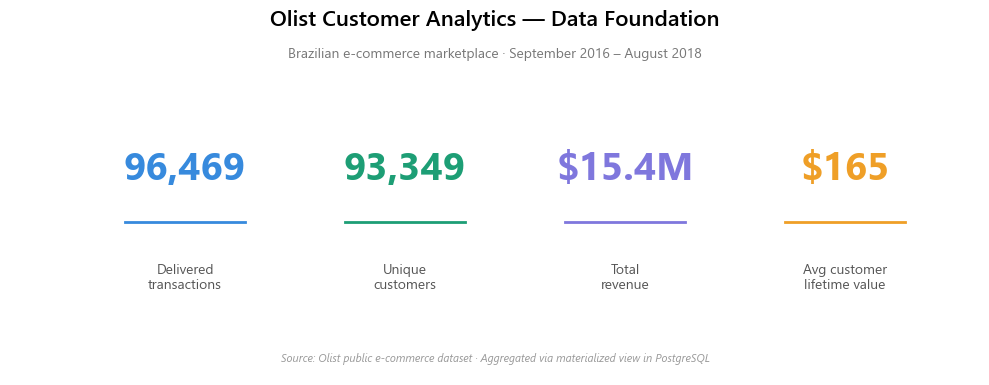

✓ Figure 1 saved to reports/figures/fig01_data_summary.png


In [11]:
# =====================================================================
# Figure 1 — Data Quality Summary Card
# =====================================================================

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')   # no axes for a card-style figure

# Title
fig.suptitle(
    'Olist Customer Analytics — Data Foundation',
    fontsize=16, fontweight='semibold', y=0.95, x=0.5, ha='center'
)
fig.text(
    0.5, 0.83,
    'Brazilian e-commerce marketplace · September 2016 – August 2018',
    fontsize=10, color='#777777', ha='center'
)

# Four KPI boxes
kpis = [
    ('96,469',      'Delivered\ntransactions',     '#378ADD'),
    ('93,349',      'Unique\ncustomers',           '#1D9E75'),
    ('$15.4M',      'Total\nrevenue',              '#7F77DD'),
    ('$165',        'Avg customer\nlifetime value','#EF9F27'),
]

for i, (value, label, color) in enumerate(kpis):
    x = 0.10 + i * 0.22

    # Big number
    fig.text(
        x + 0.09, 0.55,
        value,
        fontsize=28, fontweight='bold', color=color,
        ha='center', va='center'
    )

    # Subtitle
    fig.text(
        x + 0.09, 0.28,
        label,
        fontsize=10, color='#555555',
        ha='center', va='center'
    )

    # Thin accent line under each KPI
    fig.add_artist(
        plt.Line2D(
            [x + 0.03, x + 0.15], [0.42, 0.42],
            color=color, linewidth=2, transform=fig.transFigure
        )
    )

# Bottom note
fig.text(
    0.5, 0.07,
    'Source: Olist public e-commerce dataset · Aggregated via materialized view in PostgreSQL',
    fontsize=8, color='#999999', ha='center', style='italic'
)

plt.tight_layout()
plt.savefig('../reports/figures/fig01_data_summary.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 1 saved to reports/figures/fig01_data_summary.png")

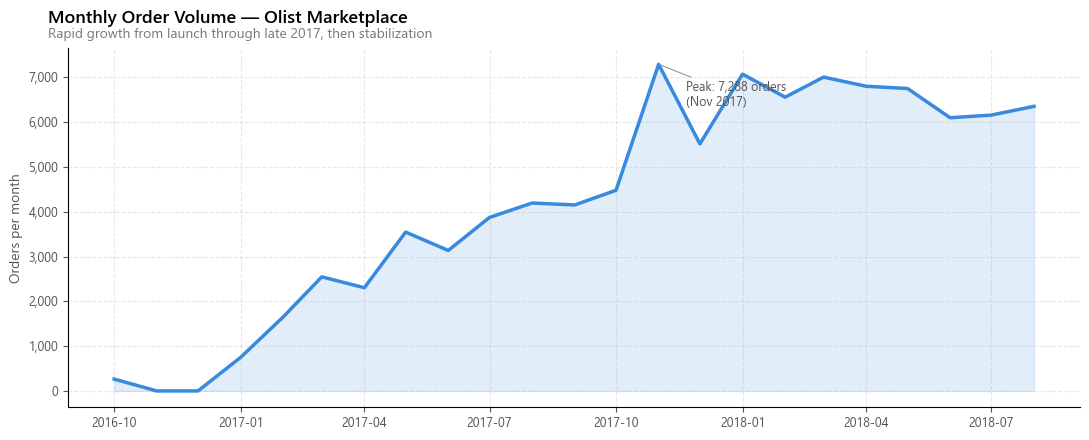

✓ Figure 2 saved to reports/figures/fig02_order_volume_over_time.png


In [12]:
# =====================================================================
# Figure 2 — Order Volume Over Time
# =====================================================================

# Aggregate orders by month
monthly_orders = (
    df.set_index('order_purchase_timestamp')
      .resample('MS')                              # MS = month start
      .agg(orders=('order_id', 'nunique'),
           revenue=('payment_value', 'sum'))
      .reset_index()
)

# Trim the very last month if it's incomplete (we said data ends 2018-08-29)
monthly_orders = monthly_orders[monthly_orders['order_purchase_timestamp'] < '2018-09-01']

# Create the figure
fig, ax = plt.subplots(figsize=(11, 4.5))

# Line + fill
ax.fill_between(
    monthly_orders['order_purchase_timestamp'],
    monthly_orders['orders'],
    color='#378ADD', alpha=0.15
)
ax.plot(
    monthly_orders['order_purchase_timestamp'],
    monthly_orders['orders'],
    color='#378ADD', linewidth=2.5
)

# Annotate peak
peak_row = monthly_orders.loc[monthly_orders['orders'].idxmax()]
ax.annotate(
    f"Peak: {int(peak_row['orders']):,} orders\n({peak_row['order_purchase_timestamp'].strftime('%b %Y')})",
    xy=(peak_row['order_purchase_timestamp'], peak_row['orders']),
    xytext=(20, -30),
    textcoords='offset points',
    fontsize=9, color='#555555',
    arrowprops=dict(arrowstyle='-', color='#999999', lw=0.8)
)

# Titles and labels
ax.set_title('Monthly Order Volume — Olist Marketplace', loc='left', x=-0.02)
ax.text(
    -0.02, 1.02,
    'Rapid growth from launch through late 2017, then stabilization',
    transform=ax.transAxes, fontsize=10, color='#777777', va='bottom'
)
ax.set_xlabel('')
ax.set_ylabel('Orders per month')

# Y-axis formatting
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../reports/figures/fig02_order_volume_over_time.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 2 saved to reports/figures/fig02_order_volume_over_time.png")

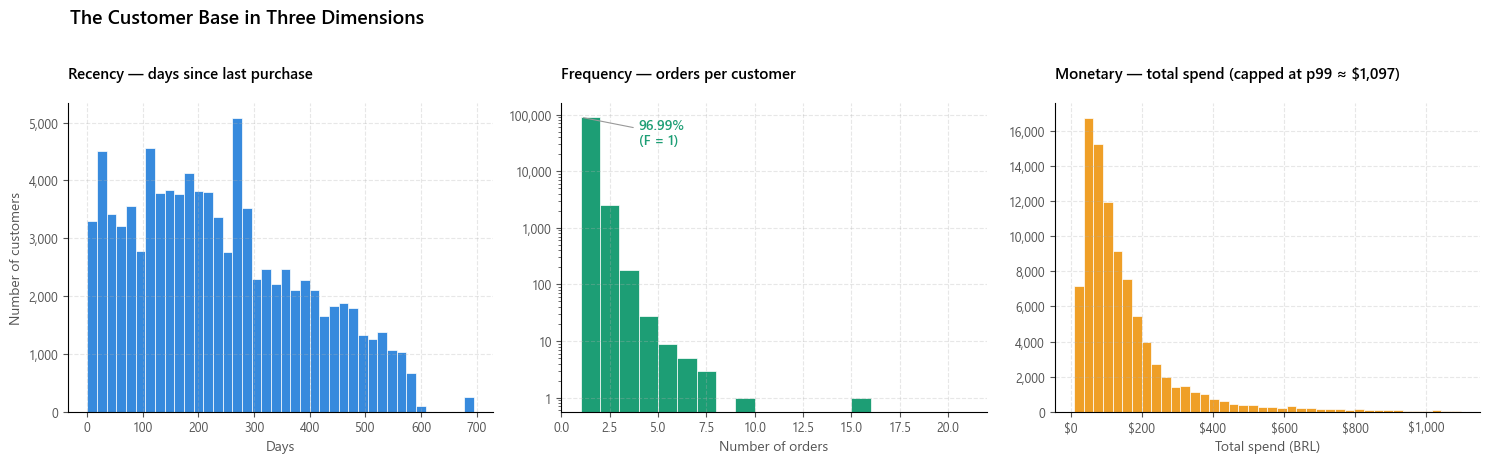

✓ Figure 3 saved to reports/figures/fig03_rfm_distributions.png


In [13]:
# =====================================================================
# Figure 3 — RFM Distributions (3-panel histograms)
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ----- Panel 1: Recency -----
axes[0].hist(rfm['recency'], bins=40, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].set_title('Recency — days since last purchase', loc='left', fontsize=11)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of customers')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ----- Panel 2: Frequency (log-scale because of the extreme skew) -----
axes[1].hist(rfm['frequency'], bins=range(1, 22), color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].set_title('Frequency — orders per customer', loc='left', fontsize=11)
axes[1].set_xlabel('Number of orders')
axes[1].set_yscale('log')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotate the F=1 dominance
axes[1].annotate(
    '96.99%\n(F = 1)',
    xy=(1, 90000), xytext=(4, 30000),
    fontsize=10, color='#1D9E75', fontweight='semibold',
    arrowprops=dict(arrowstyle='-', color='#999999', lw=0.8)
)

# ----- Panel 3: Monetary (capped at p99 for readability) -----
m_p99 = rfm['monetary'].quantile(0.99)
axes[2].hist(rfm[rfm['monetary'] <= m_p99]['monetary'], bins=40, color='#EF9F27', edgecolor='white', linewidth=0.5)
axes[2].set_title(f'Monetary — total spend (capped at p99 ≈ ${m_p99:,.0f})', loc='left', fontsize=11)
axes[2].set_xlabel('Total spend (BRL)')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Overall title
fig.suptitle(
    'The Customer Base in Three Dimensions',
    fontsize=14, fontweight='semibold', x=0.05, ha='left', y=1.02
)

plt.tight_layout()
plt.savefig('../reports/figures/fig03_rfm_distributions.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 3 saved to reports/figures/fig03_rfm_distributions.png")

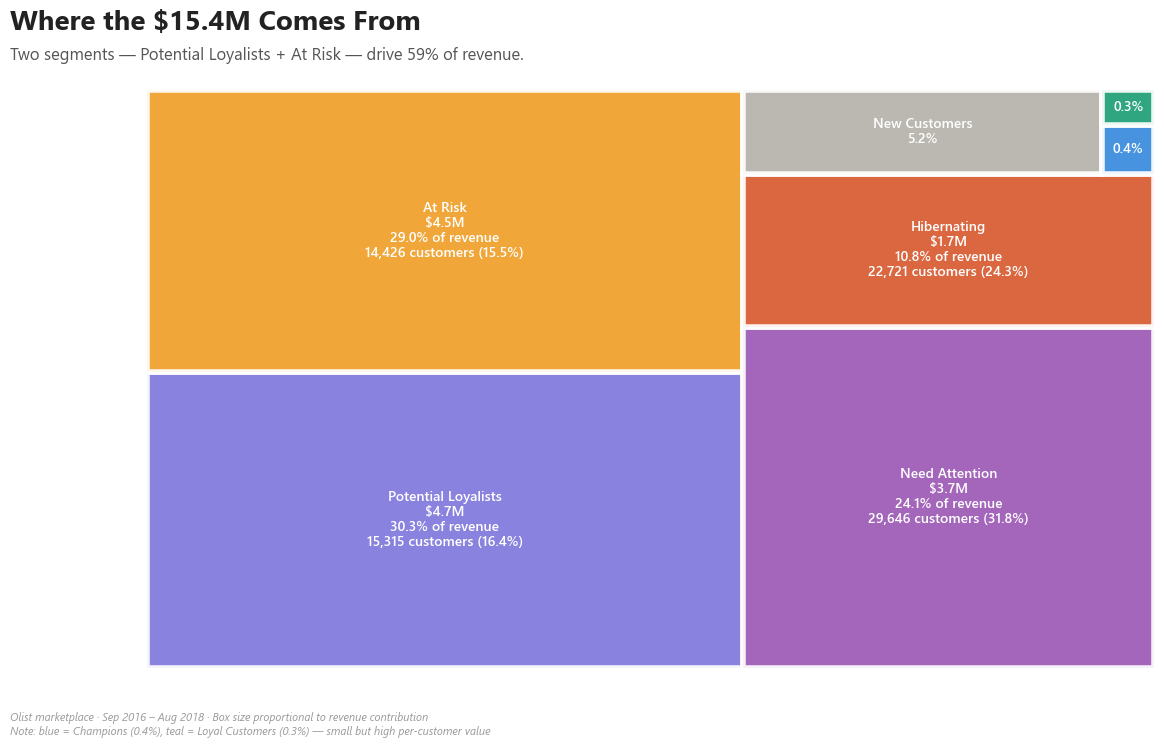

✓ Figure 4 saved to reports/figures/fig04_segment_treemap.png


In [14]:
# =====================================================================
# Figure 4 — Revenue Treemap by Segment (THE HEADLINE)
# =====================================================================

# We need a library called squarify for treemaps
import squarify

# Prepare data — segment revenue, sorted descending
treemap_data = (
    rfm.groupby('segment')
       .agg(customers=('customer_unique_id', 'count'),
            revenue=('monetary', 'sum'))
       .sort_values('revenue', ascending=False)
       .reset_index()
)

# Calculate percentages
total_revenue = treemap_data['revenue'].sum()
treemap_data['revenue_pct'] = treemap_data['revenue'] / total_revenue * 100
treemap_data['customer_pct'] = treemap_data['customers'] / treemap_data['customers'].sum() * 100

# Build labels — full detail for big segments, abbreviated for tiny ones
def make_label(row):
    if row.revenue_pct < 1:
        # Tiny segments — just percentage, name in caption
        return f"{row.revenue_pct:.1f}%"
    elif row.revenue_pct < 6:
        # Smallish segments — name + revenue % only (no $ or customer count)
        return f"{row.segment}\n{row.revenue_pct:.1f}%"
    else:
        # Big segments — full detail
        return (
            f"{row.segment}\n"
            f"${row.revenue/1e6:.1f}M\n"
            f"{row.revenue_pct:.1f}% of revenue\n"
            f"{int(row.customers):,} customers ({row.customer_pct:.1f}%)"
        )

labels = [make_label(row) for row in treemap_data.itertuples()]


# Get colors in matching order
colors = [SEGMENT_COLORS[s] for s in treemap_data['segment']]

# Create the figure
fig, ax = plt.subplots(figsize=(13, 7.5))

squarify.plot(
    sizes=treemap_data['revenue'],
    label=labels,
    color=colors,
    alpha=0.92,
    text_kwargs={'fontsize': 10, 'color': 'white', 'fontweight': 'semibold'},
    edgecolor='white',
    linewidth=4,
    ax=ax
)

ax.axis('off')

# Main title — left aligned, large
fig.text(
    0.02, 0.96,
    'Where the $15.4M Comes From',
    fontsize=20, fontweight='bold', color='#222222'
)

# Subtitle — the headline finding
fig.text(
    0.02, 0.92,
    'Two segments — Potential Loyalists + At Risk — drive 59% of revenue.',
    fontsize=12, color='#555555'
)

# Footer
fig.text(
    0.02, 0.02,
    'Olist marketplace · Sep 2016 – Aug 2018 · Box size proportional to revenue contribution\n'
    'Note: blue = Champions (0.4%), teal = Loyal Customers (0.3%) — small but high per-customer value',
    fontsize=8, color='#999999', style='italic'
)



plt.savefig('../reports/figures/fig04_segment_treemap.png', bbox_inches='tight', facecolor='white', dpi=200)
plt.show()

print("✓ Figure 4 saved to reports/figures/fig04_segment_treemap.png")

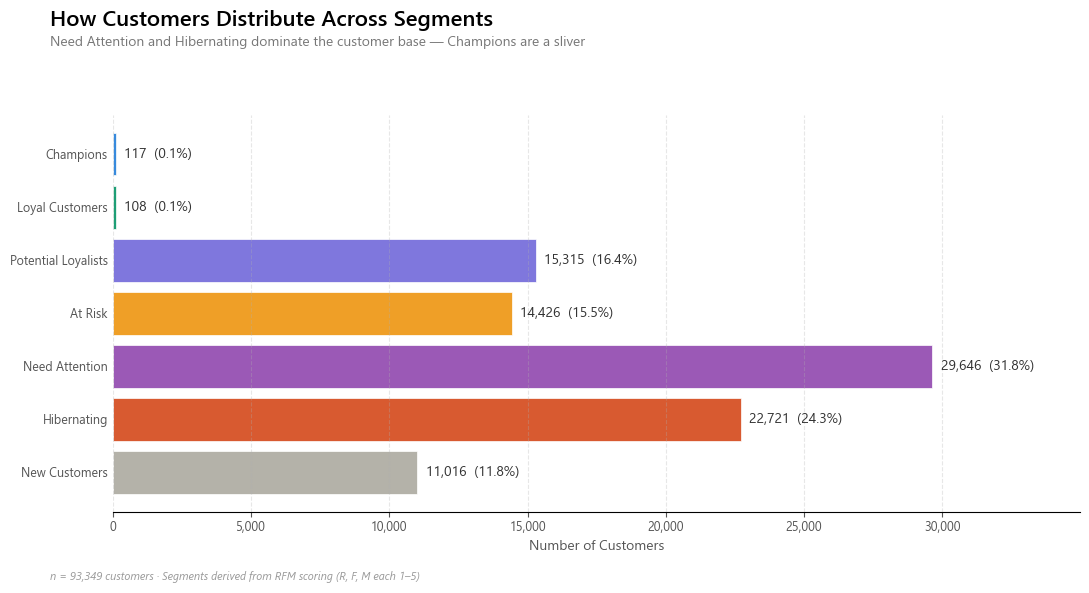

✓ Figure 5 saved to reports/figures/fig05_segment_sizes.png


In [15]:
# =====================================================================
# Figure 5 — Segment Size Bar Chart
# =====================================================================

# Compute customer counts per segment from the rfm DataFrame
segment_counts = (
    rfm['segment']
    .value_counts()
    .reindex(SEGMENT_ORDER)
    .dropna()
    .astype(int)            # ← add this line
)

# Total customers — used for percentage labels
total_customers = segment_counts.sum()

# Build the figure
fig, ax = plt.subplots(figsize=(11, 6))

# Horizontal bar chart — easier to read with long segment names
bars = ax.barh(
    y=segment_counts.index,
    width=segment_counts.values,
    color=[SEGMENT_COLORS[s] for s in segment_counts.index],
    edgecolor='white',
    linewidth=0.5,
)

# Invert y-axis so the largest segment is on top
ax.invert_yaxis()

# Title & subtitle
fig.suptitle(
    'How Customers Distribute Across Segments',
    fontsize=16, fontweight='semibold', x=0.05, y=0.97, ha='left'
)
fig.text(
    0.05, 0.91,
    'Need Attention and Hibernating dominate the customer base — Champions are a sliver',
    fontsize=10, color='#777777', ha='left'
)

# Data labels at the end of each bar — count + percentage
for bar, count in zip(bars, segment_counts.values):
    pct = count / total_customers * 100
    ax.text(
        bar.get_width() + (segment_counts.max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}  ({pct:.1f}%)',
        va='center', ha='left',
        fontsize=10, color='#333333',
    )

# Axis formatting
ax.set_xlabel('Number of Customers', fontsize=10)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, segment_counts.max() * 1.18)   # room for labels
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.grid(axis='y', visible=False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

# Bottom note
fig.text(
    0.05, 0.02,
    f'n = {total_customers:,} customers · Segments derived from RFM scoring (R, F, M each 1–5)',
    fontsize=8, color='#999999', ha='left', style='italic'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.savefig('../reports/figures/fig05_segment_sizes.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 5 saved to reports/figures/fig05_segment_sizes.png")

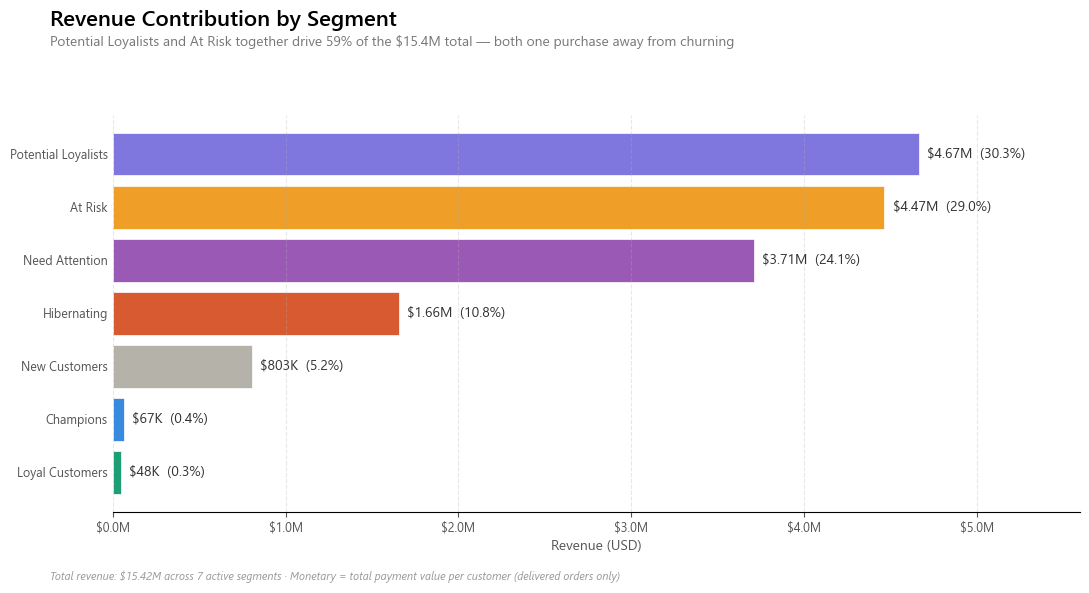

✓ Figure 6 saved to reports/figures/fig06_segment_revenue.png


In [16]:
# =====================================================================
# Figure 6 — Revenue Contribution Per Segment
# =====================================================================

# Compute total revenue per segment from the rfm DataFrame
segment_revenue = (
    rfm.groupby('segment')['monetary']
    .sum()
    .reindex(SEGMENT_ORDER)
    .dropna()
)

# Sort descending by revenue (largest contributor on top)
segment_revenue = segment_revenue.sort_values(ascending=False)

# Total revenue — used for percentage labels
total_revenue = segment_revenue.sum()

# Build the figure
fig, ax = plt.subplots(figsize=(11, 6))

# Horizontal bar chart — matches Figure 5's format for visual pairing
bars = ax.barh(
    y=segment_revenue.index,
    width=segment_revenue.values,
    color=[SEGMENT_COLORS[s] for s in segment_revenue.index],
    edgecolor='white',
    linewidth=0.5,
)

# Largest revenue contributor on top
ax.invert_yaxis()

# Title & subtitle
fig.suptitle(
    'Revenue Contribution by Segment',
    fontsize=16, fontweight='semibold', x=0.05, y=0.97, ha='left'
)
fig.text(
    0.05, 0.91,
    'Potential Loyalists and At Risk together drive 59% of the $15.4M total — both one purchase away from churning',
    fontsize=10, color='#777777', ha='left'
)

# Data labels at the end of each bar — $ value + percentage
for bar, revenue in zip(bars, segment_revenue.values):
    pct = revenue / total_revenue * 100
    # Format revenue in millions if >= $1M, else thousands
    if revenue >= 1_000_000:
        revenue_str = f'${revenue / 1_000_000:.2f}M'
    else:
        revenue_str = f'${revenue / 1_000:.0f}K'

    ax.text(
        bar.get_width() + (segment_revenue.max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{revenue_str}  ({pct:.1f}%)',
        va='center', ha='left',
        fontsize=10, color='#333333',
    )

# Axis formatting
ax.set_xlabel('Revenue (USD)', fontsize=10)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'${x / 1_000_000:.1f}M')
)
ax.set_xlim(0, segment_revenue.max() * 1.20)   # room for labels
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.grid(axis='y', visible=False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

# Bottom note
fig.text(
    0.05, 0.02,
    f'Total revenue: ${total_revenue / 1_000_000:.2f}M across {len(segment_revenue)} active segments · '
    f'Monetary = total payment value per customer (delivered orders only)',
    fontsize=8, color='#999999', ha='left', style='italic'
)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.savefig('../reports/figures/fig06_segment_revenue.png', bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Figure 6 saved to reports/figures/fig06_segment_revenue.png")

## RFM Segmentation Key Findings

**The customer base is structurally one purchase deep.** 96.88% of customers made exactly one purchase across the 22 months of data. Combined with the marketplace's rapid early growth pattern (Figure 2), this means traditional "Champion" segments are nearly empty. Champions and Loyal Customers together represent just 0.6% of customers and 0.7% of revenue.

**Revenue is concentrated in two segments that are vulnerable to churn.** Potential Loyalists (30.3%) and At Risk (29.0%) together drive **59% of the $15.4M total revenue**, and by definition both segments sit one purchase away from churning. This is the central tension of the analysis: the most valuable customers are also the least secure.

**Customer count and revenue share are decoupled.** Need Attention has the most customers (31.8%) but generates 24.1% of revenue. Hibernating has 24.3% of customers but only 10.8% of revenue. Marketing dollars allocated by headcount will systematically overinvest in segments where each customer is worth less and underinvest in segments where each customer is worth more.

**Strategic implication.** Retention dollars should concentrate on Potential Loyalists (preserve their next purchase) and At Risk (recover them before they slip into Hibernating). The next phase quantifies the dollar value of this intervention via probabilistic CLV modeling.